In [10]:
!pip install ipytest

In [11]:
import ipytest
import pytest
ipytest.autoconfig()

In [12]:
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

class ModelTrainerEvaluator:
    def __init__(self, X_train, X_test, y_train, y_test):
        """
        Inicializa la clase con los conjuntos de entrenamiento y prueba.
        """
        self.X_train = X_train
        self.X_test = X_test
        self.y_train = y_train
        self.y_test = y_test
        self.results = {}

    def show_class_distribution(self):
        """
        Muestra la distribución de clases en el conjunto de entrenamiento.
        """
        dist = self.y_train.value_counts(normalize=True).mul(100).round(1).astype(str) + '%'
        print(f"Distribución de clases:\n{dist}")

    def correlation_with_target(self):
        """
        Calcula la correlación de las variables independientes con la variable objetivo.
        """
        df = pd.concat([pd.DataFrame(self.X_train), pd.Series(self.y_train, name='target')], axis=1)
        corr = abs(df.corr()['target'].sort_values(ascending=False))
        print("Correlación con la variable dependiente:\n", corr)

    def apply_smote(self):
        """
        Aplica SMOTE para balancear las clases en el conjunto de entrenamiento.
        """
        smote = SMOTE(random_state=42)
        X_resampled, y_resampled = smote.fit_resample(self.X_train, self.y_train)
        return X_resampled, y_resampled
    def train_and_evaluate(self, model_name, model):
        """
        Entrena y evalúa un modelo, mostrando matriz de confusión y reporte de clasificación.
        """
        # Aplicar SMOTE
        X_resampled, y_resampled = self.apply_smote()

        # Entrenar el modelo
        model.fit(X_resampled, y_resampled)

        # Predicción
        y_pred = model.predict(self.X_test)

        # Matriz de confusión
        cm = confusion_matrix(self.y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Pred 0', 'Pred 1'], yticklabels=['Real 0', 'Real 1'])
        plt.title(f'Matriz de Confusión - {model_name}')
        plt.show()

        # Reporte de clasificación
        report = classification_report(self.y_test, y_pred, zero_division=0, output_dict=True)
        print(f"\nReporte de clasificación - {model_name}:")
        print(classification_report(self.y_test, y_pred, zero_division=0))

        # Guardar resultados
        self.results[model_name] = report

    def run_model(self, model):
        """
        Ejecuta el entrenamiento y evaluación para el modelo.
        """

        # Obtener el nombre del modelo dinámicamente
        model_name = model.__class__.__name__

        self.train_and_evaluate(model_name, model)

In [13]:
@pytest.fixture
def trainer():
    from sklearn.datasets import make_classification
    from sklearn.model_selection import train_test_split

    # Crear un dataset desequilibrado para probar SMOTE
    X, y = make_classification(n_samples=200, n_features=5, n_informative=3,
                               n_redundant=0, n_clusters_per_class=1,
                               weights=[0.85, 0.15], flip_y=0, random_state=42)

    # Dividir en entrenamiento y prueba
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    # Crear instancia de la clase
    return ModelTrainerEvaluator(X_train, X_test, y_train, y_test)

...

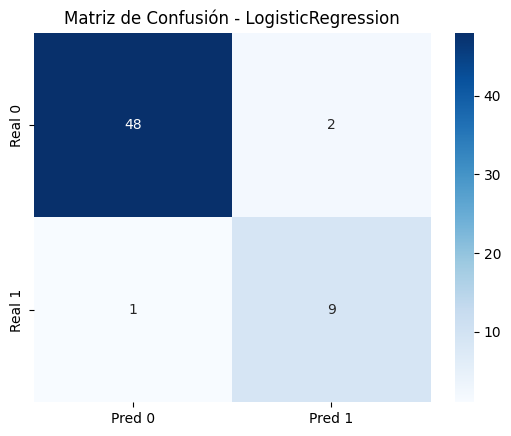

.

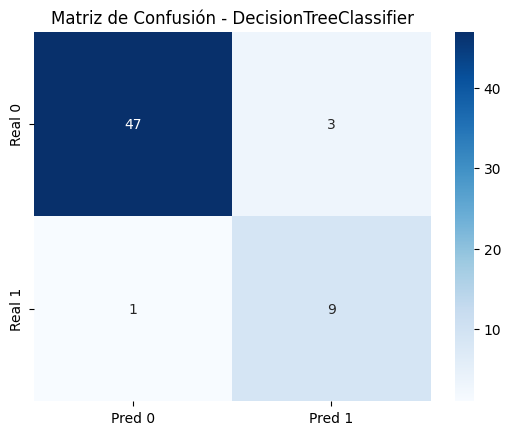

.                                                                                        [100%]
5 passed in 0.59s


In [14]:

%%ipytest

'''Verifica que se imprima la distribución de clases correctamente'''
def test_show_class_distribution(trainer):
    # No hay retorno, pero podemos verificar que los valores existen
    dist = pd.Series(trainer.y_train).value_counts(normalize=True)
    assert dist.sum() == pytest.approx(1.0, abs=0.01)

'''Verifica que se calcule la correlación con la variable objetivo'''
def test_correlation_with_target(trainer):
    trainer.correlation_with_target()
    df = pd.concat([pd.DataFrame(trainer.X_train), pd.Series(trainer.y_train, name='target')], axis=1)
    corr = df.corr()['target']
    assert isinstance(corr, pd.Series)
    assert not corr.isnull().all()

'''Verifica que SMOTE balancea las clases'''
def test_apply_smote(trainer):
    X_resampled, y_resampled = trainer.apply_smote()
    unique, counts = np.unique(y_resampled, return_counts=True)
    # Las clases deben estar balanceadas
    assert counts[0] == counts[1]

'''Verifica que se entrena y evalúa correctamente con LogisticRegression'''
def test_train_and_evaluate_logistic(trainer):
    trainer.train_and_evaluate("LogisticRegression", LogisticRegression())
    assert "LogisticRegression" in trainer.results
    report = trainer.results["LogisticRegression"]
    assert "accuracy" in report

'''Verifica que run_model funciona con otro modelo (DecisionTree)'''
def test_run_model_decision_tree(trainer):
    trainer.run_model(DecisionTreeClassifier())
    assert "DecisionTreeClassifier" in trainer.results
    report = trainer.results["DecisionTreeClassifier"]
    assert "accuracy" in report
